# <a id='toc1_'></a>[Auswertungen: kolorektale Krebserkrankungen](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Auswertungen: kolorektale Krebserkrankungen](#toc1_)    
  - [📆 Datenstand](#toc1_1_)    
  - [⚙️ Teildatensatz](#toc1_2_)    
  - [Fallzahlen](#toc1_3_)    
    - [Teildatensatz](#toc1_3_1_)    
    - [Fallzahlen C18-C20 in Verhältnis zu allen Diagnosen](#toc1_3_2_)    
    - [Fallzahlen C18-C20 nach Viersteller](#toc1_3_3_)    
  - [OP](#toc1_4_)    
    - [Operation erfolgt bei C18 mit T_p > 0](#toc1_4_1_)    
    - [Operation erfolgt nach Jahren](#toc1_4_2_)    
  - [OPS](#toc1_5_)    
    - [OPS 5-4xx nach Diagnose](#toc1_5_1_)    
    - [ Verteilung OPS 5-455 bei C18](#toc1_5_2_)    
    - [ Verteilung OPS 5-484 bei C20](#toc1_5_3_)    
    - [Details OPS 5-455.2](#toc1_5_4_)    
      - [Ileozökalresektion](#toc1_5_4_1_)    
      - [rechte Hemikolektomie](#toc1_5_4_2_)    
      - [Sigmaresektion](#toc1_5_4_3_)    
  - [Lokalisation (Fernmetastasen)](#toc1_6_)    
    - [für M1](#toc1_6_1_)    
  - [Rezidive](#toc1_7_)    
    - [Verteilung OP in 2020](#toc1_7_1_)    
      - [davon: Verteilung nur R0](#toc1_7_1_1_)    
  - [Behandlung innerhalb von 6 Wochen](#toc1_8_)    
  - [Erste Behandlung](#toc1_9_)    
    - [Was wurde zuerst behandelt](#toc1_9_1_)    
    - [Zeitlicher Abstand der Behandlungen](#toc1_9_2_)    
  - [Behandlungsverlauf](#toc1_10_)    
  - [🕹️ interaktiv](#toc1_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


1. Kohortenstruktur (ICD-Differenzierung)
Ich würde im ersten Schritt die Kohorte C18–C20 noch aufteilen in:
•              C18
•              C19
•              C20

und die Fallzahlen separat ausweisen. Auf dieser Basis könnten wir dann getrennt weiterarbeiten. Vermutlich werden die C19-Zahlen eher klein sein, sodass man diese ggf. in den weiteren Analysen aus methodischen Gründen ausklammern kann.

2. OPS-Analyse getrennt nach Lokalisation
Bei den OPS würde ich nicht mehr mit dem Sammelfilter C18–C20 arbeiten, sondern drei getrennte Analysen fahren:
•              einmal nur C18
•              einmal nur C19
•              einmal nur C20

Idealerweise jeweils als vollständige Liste (6-stellige OPS-Codes) mit absoluter Anzahl – ggf. als Excel-Export.
Hier wäre auch wichtig zu klären, wie wir Doppelnennungen (mehrere OPS pro Tumor) sauber behandeln oder identifizieren können.

3. Zeitverlauf statt nur regionale Darstellung
Die übliche Darstellung ist ja stark register- bzw. bundeslandbezogen. Zusätzlich fände ich sehr spannend, das Ganze auch im Zeitverlauf darzustellen:
•              2020
•              2021
•              2022
•              2023

und zu sehen, ob sich OP-Techniken oder Dokumentationsqualität verändern.

4. Robotik-Kodierung
Ergänzend sollten wir berücksichtigen, dass der „echte“ Roboter über OPS 5-987.01 generiert wird. Das wäre wichtig, um Robotik korrekt zu identifizieren.


In [69]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from pandas_plots.hlp import add_bitmask_label
import duckdb as ddb

hlp.show_package_version()
# hlp.show_package_version(["pygwalker", "plotly"])

os.environ["RENDERER"] = ""
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
# file_db_clin = dir_db/'2026-02-26_data_clin.duckdb'
# file_db_clin = dir_db/'fake_data_clin.duckdb'
if not file_db_clin.exists():
    raise FileNotFoundError(file_db_clin)

if not os.path.exists(".local"):
    os.makedirs(".local")

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.6 | 📦 connection-helper: 0.13.3


In [2]:
con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

## <a id='toc1_1_'></a>[📆 Datenstand](#toc0_)

In [3]:
sql.print_meta(file_db_clin)

database file:           2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2026-03-03 14:05:17


## <a id='toc1_2_'></a>[⚙️ Teildatensatz](#toc0_)
- Filter für gültige Fälle: (dieser Filter ist für **alle** Analysen gesetzt)
  - `z_dy` (Diagnosejahr) in 2020-2023
  - nichtleere angaben zu
    - `z_kkr` (lieferndes Krebsregister)
    - `z_age` (Diagnosealter)
    - `z_icd10` (Primärdiagnose)
- Fachlicher Filter:
  - `z_icd10` (Primärdiagnose) in `C18`-`C20`
- aktuelle Fallzahlen mit diesen Filtern
  - Tumore: **226_006**

In [ ]:
# # * settings
DY_MAX = 2024

FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
# FILTER_KKR = "z_kkr_label is not null"
# FILTER_AGE = "z_ag05 is not null"
FILTER_DEFAULT = f"""--sql
    {FILTER_DY}
"""
    # and {FILTER_KKR}
    # and {FILTER_AGE}


FILTER_COLORECTAL = "z_icd10_3d in ('C18','C19','C20')"

In [ ]:
FILTERS = [
    (FILTER_DY, ""),
    # (FILTER_KKR, ""),
    # (FILTER_AGE, ""),
    (FILTER_COLORECTAL, ""),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=FILTERS,
    # distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: rows
---
n = 3_241_401                                        (100.0%) ██████████████████████████████
└ [z_dy between 2020 and 2024]:        n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [z_kkr_label is not null]:           n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [z_ag05 is not null]:                n = 2_998_752  (92.5%) ░░░███████████████████████████
└ [z_icd10_3d in ('C18','C19','C20')]:   n = 227_053   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

In [6]:
# # * co-li-sy-st
db_treatment_first_co_li_sy_st = (con.sql("""--sql
        -- all tum_id w/ a first_treatment variable that codes the values as bitmask (colon = 1, liver = 2, syst = 4 etc)
        -- do not code a set like "has x but not y" for ops since there are overlaps
        -- use bit operation '&' to filter: WHERE treatment_first_co_li_sy_st & 4 = 4;
        select  z_tum_id, 
            max(colon) + max(liver) * 2 + max(syst) * 4 + max(st) * 8 as treatment_first_co_li_sy_st
        from (
            select 
                tu.z_tum_id,
                case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-455','5-484','5-485') then 1 else 0 end as colon, 
                case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-501', '5-502', '5-503') then 1 else 0 end as liver,
                case when tu.z_first_treatment = 'sy' then 1 else 0 end as syst,
                case when tu.z_first_treatment = 'st' then 1 else 0 end as st,
            from Tumor tu 
            left join SYST syst on tu.z_tum_id = syst.z_tum_id
            left join OP op on tu.z_tum_id = op.z_tum_id
            left join OPS ops on op.OPId = ops.OP_TypId
        ) t
        group by z_tum_id
    """)
    .add_bitmask_label(bitmask_col='treatment_first_co_li_sy_st', labels=['co', 'li', 'sy', 'st'], con=con)
    .project("z_tum_id, treatment_first_co_li_sy_st_label as treatment_first_co_li_sy_st")
)

# tbl.descr_db(db_treatment_first_co_li_sy_st, 'treatment_first_co_li_sy_st')

In [7]:
# # * Leber Gruppen
db_liver_grps = (con.sql("""--sql
        select  z_tum_id, 
            max(g1) + max(g2) * 2 + max(g3) * 4 + max(g4) * 8 + max(g5) * 16 + max(g6) * 32 + max(g7) * 64 + max(g8) * 128 as liver_grps
        from (
            select 
                tu.z_tum_id,
                case when substr(ops.Code,1,8) in ('5-455.21') then 1 else 0 end as g1,
                case when substr(ops.Code,1,8) in ('5-455.25') then 1 else 0 end as g2,
                case when substr(ops.Code,1,8) in ('5-455.27') then 1 else 0 end as g3,
                case when substr(ops.Code,1,8) in ('5-455.31') then 1 else 0 end as g4,
                case when substr(ops.Code,1,8) in ('5-455.35') then 1 else 0 end as g5,
                case when substr(ops.Code,1,8) in ('5-455.37') then 1 else 0 end as g6,
                case when substr(ops.Code,1,8) in ('5-455.41') then 1 else 0 end as g7,
                case when substr(ops.Code,1,8) in ('5-455.45') then 1 else 0 end as g8
            from Tumor tu
            left join SYST syst on tu.z_tum_id = syst.z_tum_id
            left join OP op on tu.z_tum_id = op.z_tum_id
            left join OPS ops on op.OPId = ops.OP_TypId
        ) t
        group by z_tum_id
    """)
    .add_bitmask_label(bitmask_col='liver_grps', labels=['g21', 'g25', 'g27', 'g31', 'g35', 'g37', 'g41', 'g45'], con=con)
    .project("z_tum_id, liver_grps_label as liver_grps")
)
# tbl.descr_db(db_liver_grps, 'liver_grps')

In [8]:
# con.sql("describe tumor").fetchall()

In [9]:
# # * Tabelle

# * table id and respective dates (eg. op, st, syst, bestr) are included to give a complete picture of the data
# * first create complete dataset incl all icd10 (>4mio rows) for survey analysis, but reduce to C18C20 after
db_allicd = (con.sql("""--sql
    select 
        tum.z_tum_id,
        tum.z_kkr_label,
        z_icd10, 
        z_icd10_3d,-- icd10_1d,
        z_dy,
        z_sex,
        z_t_p_1, z_t_c_1, z_n_p_1, z_m_pc_1, z_m_p_0,
        coalesce(z_t_p_1, z_t_c_1) as z_t_pc_1,
        uicc.code_1 as UICC_Stadium_p_1,
        z_ag05, 
        z_age,
        --z_tum_st_count, z_tum_op_count, z_tum_sy_count,
        dsich.name as Diagnosesicherung,

        z_pat_id,
        pat.Verstorben,

        op.OPId as op_id, op.Datum_OP,
        z_op_order, dim_op_intention.name as Intention_OP, dim_r_typ.name as OP_Lokale_Beurteilung_Residualstatus,

        syst.SYSTId as syst_id, syst.Datum_Beginn_SYST,
        dim_syst_intention.name as Intention_SYST, syst.Therapieart,
        
        st.STId as st_id, 
        dim_st_intention.name as Intention_ST, dim_st_op_stellung.name as ST_Stellung_OP,

        bestr.BestrahlungId as bestr_id, bestr.Datum_Beginn_Bestrahlung,
        
        folge.FolgeereignisId as folge_id, folge.Datum_Folgeereignis,
        dim_verlauf_lokal.name as Folge_Verlauf_Lokaler_Tumorstatus,

        dim_fm_lokalisation.name as FM_Lokalisation,
        
        RASMutation,
        RektumAbstandAnokutanlinie,

        z_first_treatment, 
        z_first_treatment_after_days,
        z_tum_st_count, z_tum_op_count, z_tum_sy_count, z_tum_fo_count,
        (z_tum_op_count > 0) as tum_has_op,
        db_treatment_first_co_li_sy_st.treatment_first_co_li_sy_st,
        db_liver_grps.liver_grps,
        z_last_tum_status,

        case when z_icd10_3d in ('C18','C19','C20') then cast(true as bool) else cast(false as bool) end as 'C18C20',
    from Tumor tum
    join Patient pat on tum.oBDS_RKIPatientId = pat.oBDS_RKIPatientId
    left join db_treatment_first_co_li_sy_st on tum.z_tum_id = db_treatment_first_co_li_sy_st.z_tum_id
    left join db_liver_grps on tum.z_tum_id = db_liver_grps.z_tum_id
    left join dim_diagnosesicherung_clin dsich on dsich.code = Diagnosesicherung
    left join SYST syst on tum.z_tum_id = syst.z_tum_id
    left join ST st on tum.z_tum_id = st.z_tum_id
    left join Bestrahlung bestr on st.STId = bestr.STId
    left join OP op on tum.z_tum_id = op.z_tum_id
    left join dim_tnm_uicc uicc on UICC_Stadium_p = uicc.code
    left join Folgeereignis folge on tum.z_tum_id = folge.z_tum_id
    left join Diagnose_Fernmetastase fm on tum.z_tum_id = fm.z_tum_id
    left join dim_beurteilung_gesamt dim_folge_1 on Gesamtbeurteilung_Tumorstatus = dim_folge_1.code
    left join dim_fm_lokalisation on Lokalisation = dim_fm_lokalisation.code
    left join dim_verlauf_lokal on folge.Verlauf_Lokaler_Tumorstatus = dim_verlauf_lokal.code
    left join dim_op_intention on op.Intention = dim_op_intention.code
    left join dim_st_intention on st.Intention = dim_st_intention.code
    left join dim_st_op_stellung on st.Stellung_OP = dim_st_op_stellung.code
    left join dim_syst_intention on syst.Intention = dim_syst_intention.code
    left join dim_r_typ on op.Lokale_Beurteilung_Residualstatus = dim_r_typ.code
    """)
    .filter(f"{FILTER_DEFAULT}")
)

# * derive colorectal dataset
db_colon = db_allicd.filter(f"{FILTER_COLORECTAL}")

# tbl.descr_db(db_allicd, caption="all icd", use_preview=False)
# tbl.descr_db(db_colon, caption="colorectal", use_preview=True)

In [10]:
db_tum = con.sql(f"""--sql
        select * 
        from Tumor
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}
        """)
# tbl.descr_db(db_tum, "tum")

In [11]:
db_syst = con.sql("""--sql
        select z_tum_id, Intention, Stellung_OP, Therapieart, Anzahl_Tage_Diagnose_SYST, Anzahl_Tage_SYST_Dauer, z_syst_order
        from SYST
        """)
# tbl.descr_db(db_syst, "syst")

In [12]:
# # * validation
n = con.sql(f"select count(*) from Tumor where {FILTER_DEFAULT} and {FILTER_COLORECTAL}").fetchone()[0]
n_db =db_colon.count("distinct z_tum_id").fetchone()[0]
# print(f"Anzahl Tumore im Filter: {n:_} {'✅' if n == n_db else '❌'}")
# print(f"FILTER: {FILTER_COLORECTAL} | darin {n:_} Tumore {"✅" if n == n_db else "❌"}")

In [13]:
# # * show single tum_id records for validation

# (con.sql("""--sql
#         select 
#             tum.z_tum_id,
#             tum.z_first_treatment, 
#             st.*,
#             --op.Datum_OP, 
#             --op.z_op_order, 
#             --ops.Code,
#         from Tumor tum
#         left join ST st on tum.z_tum_id = st.z_tum_id
#         left join Bestrahlung bestr on tum.z_tum_id = bestr.z_tum_id
#         --left join SYST syst on tum.z_tum_id = syst.z_tum_id
#         --left join OP op on tum.z_tum_id = op.z_tum_id 
#         --left join OPS ops on op.OPId = ops.OP_TypId 
#         where tum.z_tum_id = '36de19e3-9d6b-4ca6-a111-434052a27ff7'
#         """)
#         # .order("Datum_OP")
#         # .to_df()
#         )

<!-- ### <a id='toc1_2_1_'></a>[Deskriptive Statistik](#toc0_) -->

In [14]:
# df = (db_colon
#     .project("* exclude (z_tum_id, z_pat_id, op_id, folge_id, bestr_id, syst_id, st_id)")
#     .to_df()
# )
# tbl.describe_df(df, caption="colorectal", top_n_chars_in_index=10, use_missing=True, use_columns=True, fig_cols=6)

## <a id='toc1_3_'></a>[Fallzahlen](#toc0_)

### <a id='toc1_3_2_'></a>[Fallzahlen C18-C20 in Verhältnis zu allen Diagnosen](#toc0_)
- Filter: alle Diagnosen inkludiert (C,D)

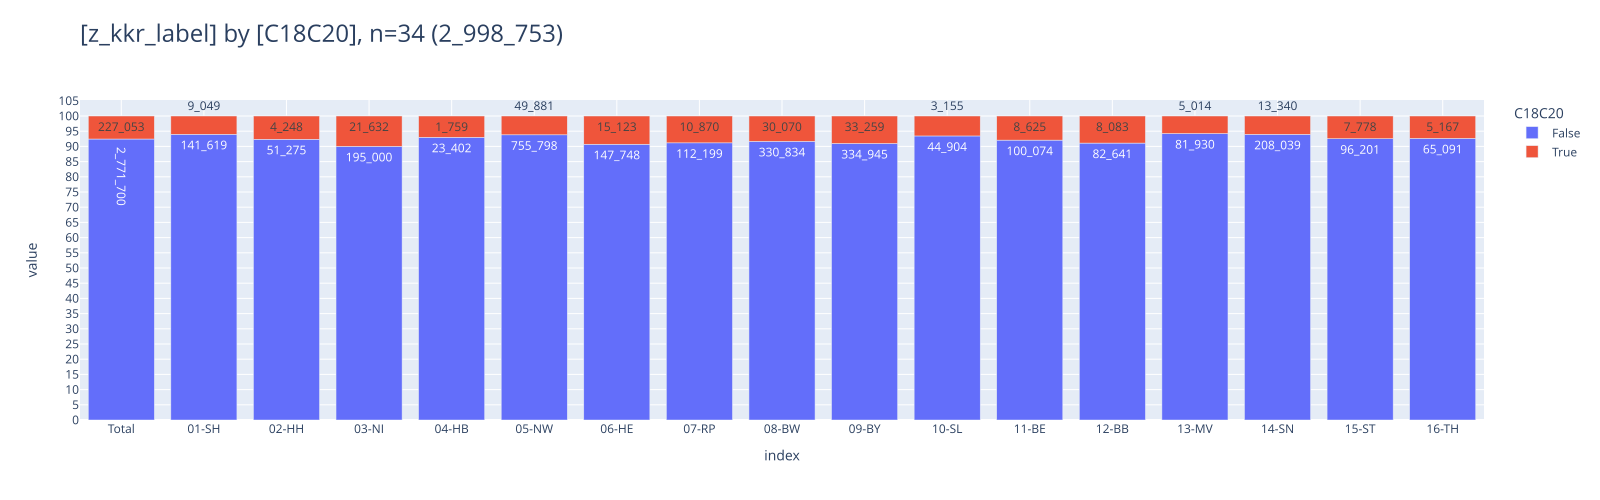

In [15]:
_df = (db_allicd
    .aggregate(aggr_expr="z_kkr_label, C18C20, count(distinct z_tum_id) as cnt")
    .to_df()
)
_=pls.plot_stacked_bars(_df, orientation="v", height=500, show_total=True, relative=True, show_pct_bar=False,)

### <a id='toc1_3_3_'></a>[Fallzahlen C18-C20 nach Viersteller](#toc0_)
- Filter: `C18-20`
> 💡 `C19` darf eigentlich nicht verwendet werden, wird von Krebsgesellschaft nicht akzeptiert

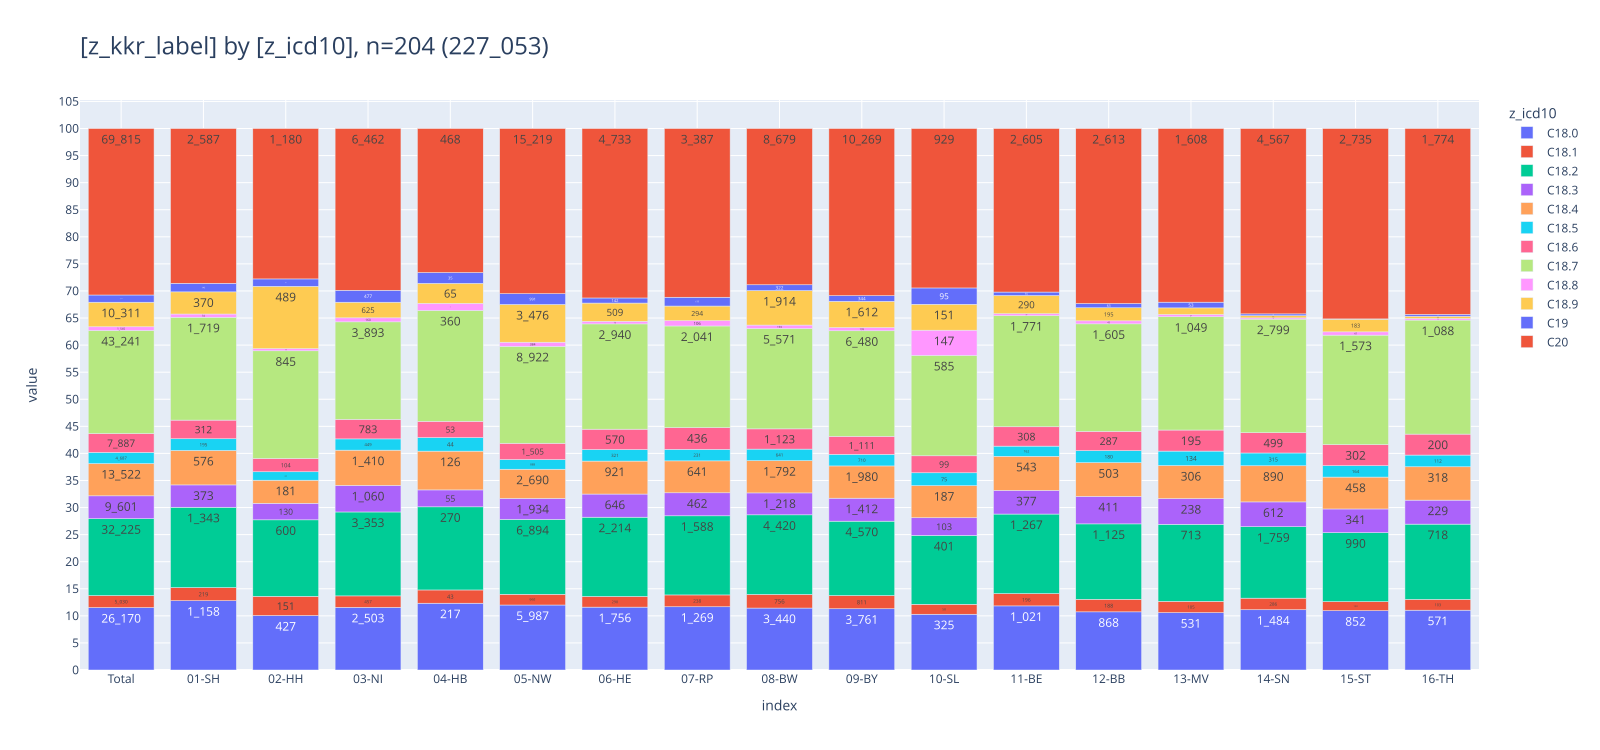

In [16]:
df = db_colon.aggregate(
    "z_kkr_label, z_icd10, count(distinct z_tum_id) as cnt"
    # "z_dy::text as z_dy, z_icd10_3d, count(distinct z_tum_id) as cnt"
).to_df()
_=pls.plot_stacked_bars(df, orientation="v", height=750, show_total=True, relative=True)
# display(tbl.pivot_df(df, data_bar_axis="x", pct_axis="x", swap=True))

## <a id='toc1_4_'></a>[OP](#toc0_)

### <a id='toc1_4_1_'></a>[Operation erfolgt bei C18 mit T_p > 0](#toc0_)
- Filter: `C18` und pathologisches T in 1-4
> 💡 5% wäre realistisch. patho stadium müsste zwingend vorhanden sein nach OP

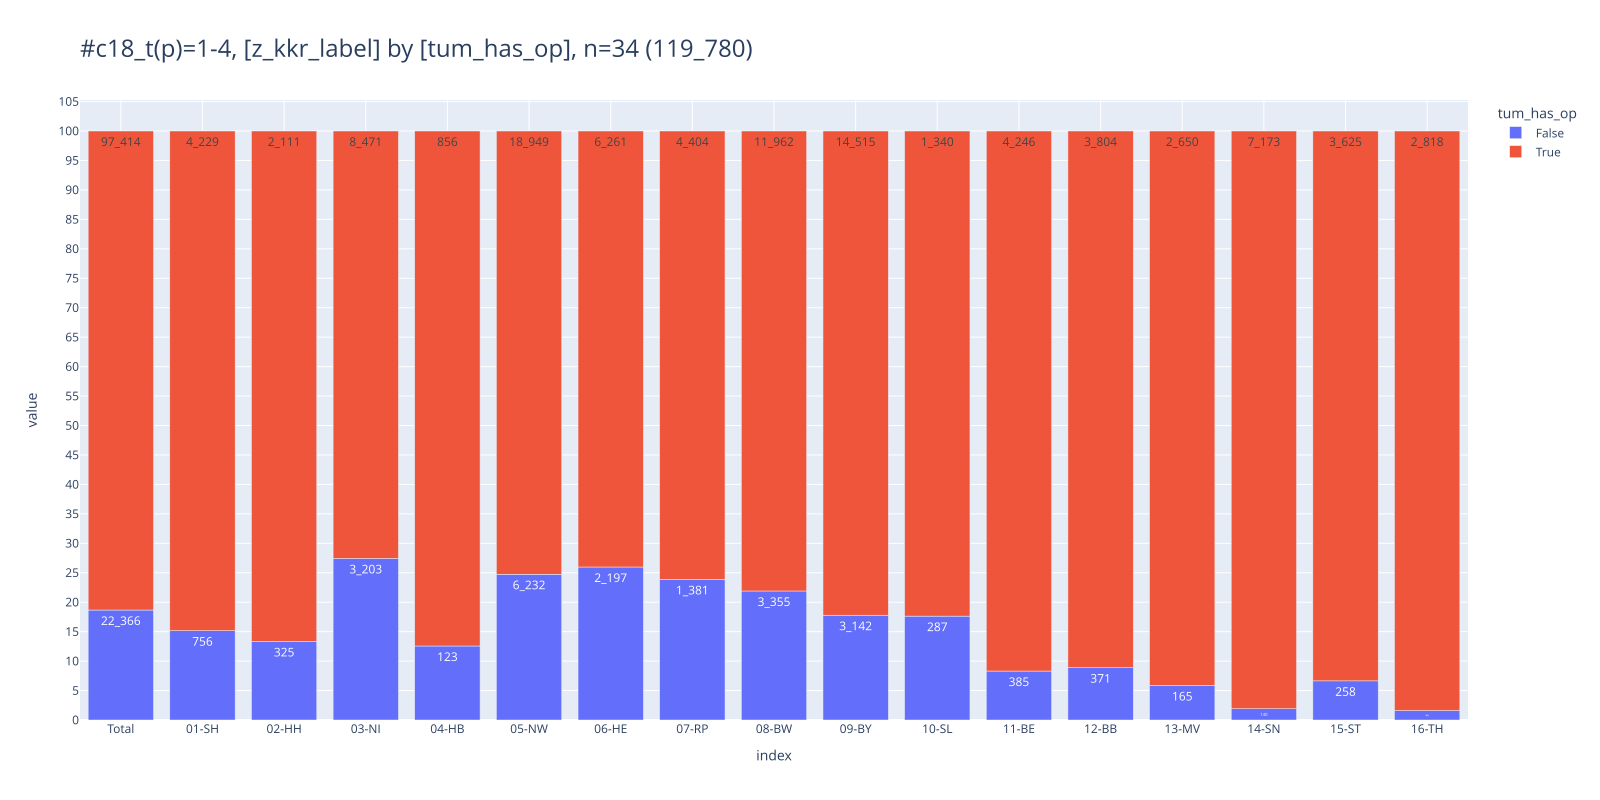

In [17]:
df = (
    db_colon.filter(
        "C18C20 and z_icd10_3d in ('C18') and z_t_p_1 in ('1','2','3','4')"
    )
    .aggregate("z_kkr_label, tum_has_op, count(distinct z_tum_id) as cnt_tum")
    .to_df()
)
_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="v",
    height=800,
    caption="c18_t(p)=1-4",
)
# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

### <a id='toc1_4_2_'></a>[Operation erfolgt nach Jahren](#toc0_)
- Filter: `C18` und pathologisches T in 1-4
- `categ_treat`
  - `1-op` - OP dokumentiert
  - `2-noop-sy-st` - keine OP dokumentiert, aber ST oder SYST
  - `3-noop-nosy-nost` - keine Behandlung dokumentiert

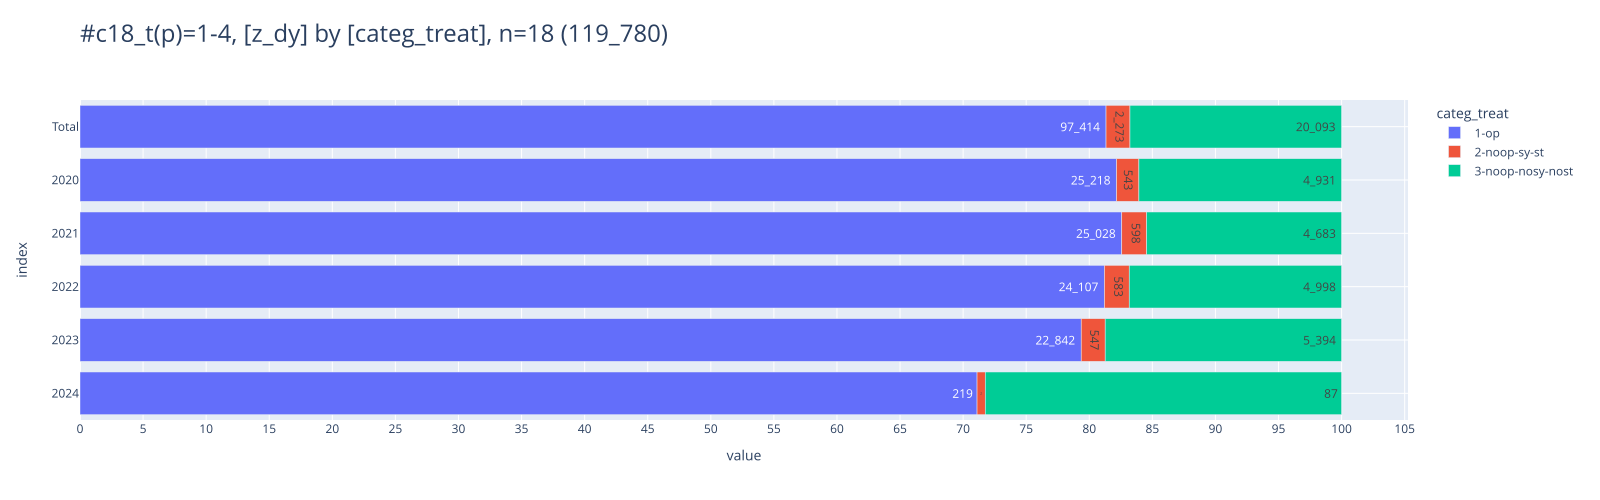

In [18]:
df = (
    db_colon.filter(
        "z_icd10_3d in ('C18') and z_t_p_1 in ('1','2','3','4')"
    )
    .project("""--sql
            *,
            case 
                when tum_has_op then '1-op' 
                when not tum_has_op and z_tum_sy_count > 0 or z_tum_st_count > 0 then '2-noop-sy-st' 
                when not tum_has_op and z_tum_sy_count = 0 and z_tum_st_count = 0 then '3-noop-nosy-nost' 
                else '9-unknown' end as categ_treat
    """)
    .aggregate("z_dy::text as z_dy, categ_treat, count(distinct z_tum_id) as cnt_tum")
    .to_df()
)
_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="h",
    height=500,
    caption="c18_t(p)=1-4",
)

## <a id='toc1_5_'></a>[OPS](#toc0_)


### <a id='toc1_5_1_'></a>[OPS 5-4xx nach Diagnose](#toc0_)
- Filter: `C18-C20`
- gezählt sind OPS Angaben, nicht Tumore

<br>

In [19]:
def show_ops(filter: str, print_table: bool = False):
    db_ops_kkr = con.sql(f"""--sql
        select
                z_kkr_label,
                ops.Code as ops_code,
                count(distinct OPSId) as cnt_ops,
                dim_ops.name as ops_name,
        from Tumor tum
        left join OP op on tum.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join dim_ops on dim_ops.code = ops.Code
        where {filter} 
        group by ops_code, z_kkr_label, ops_name
        """)
    # tbl.descr_db(db_ops_kkr, "ops_kk")

    # if print_table:
    print("Anzahl verschiedene ops_codes: ",db_ops_kkr.count("distinct ops_code").fetchone()[0])
    db_ops_kkr.aggregate("ops_code || ' - ' || ops_name as ops, sum(cnt_ops)::int as cnt_ops").order("cnt_ops desc").limit(10).show(max_width=145)
    
    hlp.print_filter(filter)

    _ = pls.plot_stacked_bars(
        db_ops_kkr.to_df().iloc[:, :3],
        # orientation="h",
        relative=True,
        top_n_color=10,
        sort_values_color=True,
        caption="c18, ops=5-4xx",
    )

Anzahl verschiedene ops_codes:  6040
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-455.41 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts…  │   24976 │
│ 5-455.45 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts…  │   15845 │
│ 5-469.20 - Andere Operationen am Darm: Adhäsiolyse: Offen chirurgisch                

<!-- START_TOKEN -->

# filter

    z_icd10_3d in ('C18')
    and left(ops.Code,3) in ('5-4')
    and 
    z_dy between 2020 and 2024




<!-- END_TOKEN -->

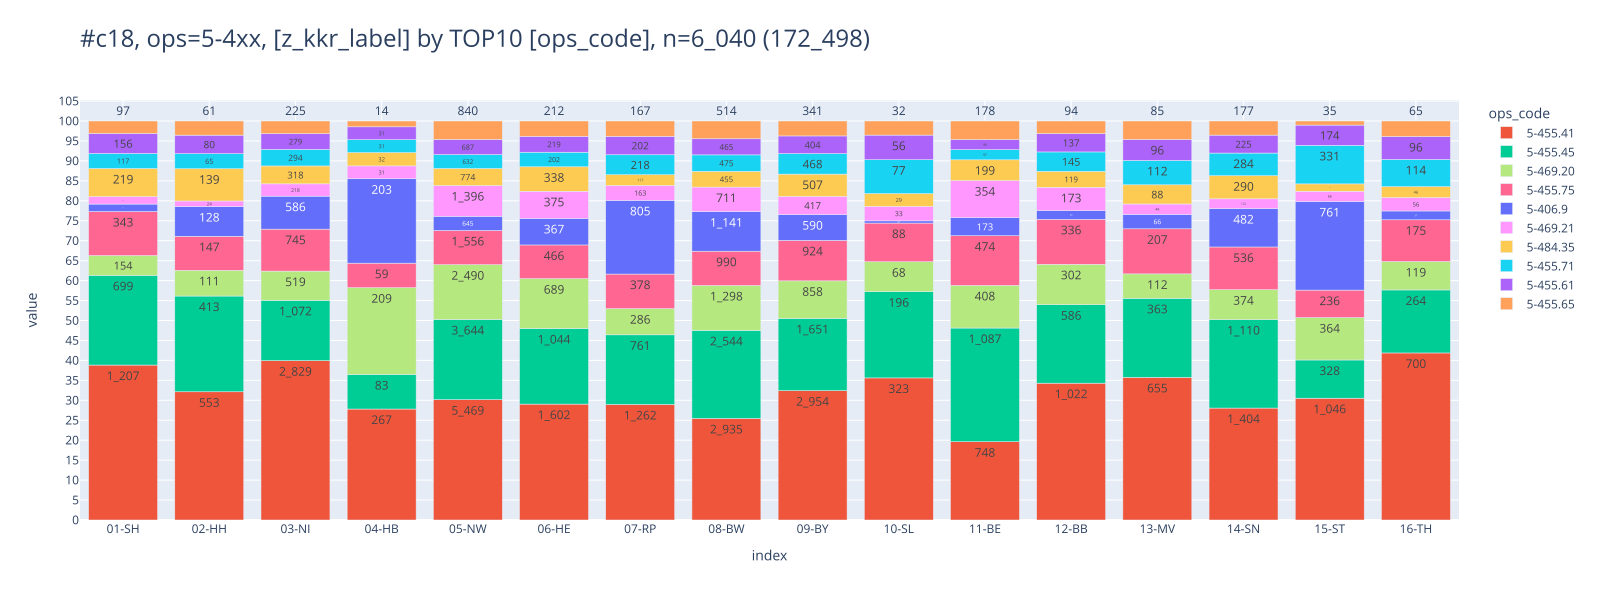

In [20]:
_filter = f"""--sql
    z_icd10_3d in ('C18')
    and left(ops.Code,3) in ('5-4')
    and {FILTER_DEFAULT}
"""

show_ops(_filter, print_table=True)

Anzahl verschiedene ops_codes:  766
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                               ops                                                               │ cnt_ops │
│                                                             varchar                                                             │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-484.35 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Laparoskopisch mit Anastomose                         │     326 │
│ 5-484.31 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Offen chirurgisch mit Anastomose                      │     146 │
│ 5-484.55 - Rektumresektion unter Sphinktererhaltung: Tiefe anteriore Resektion: Laparoskopisch mit Anastomose 

<!-- START_TOKEN -->

# filter

    z_icd10_3d in ('C19')
    and left(ops.Code,3) in ('5-4')
    and 
    z_dy between 2020 and 2024




<!-- END_TOKEN -->

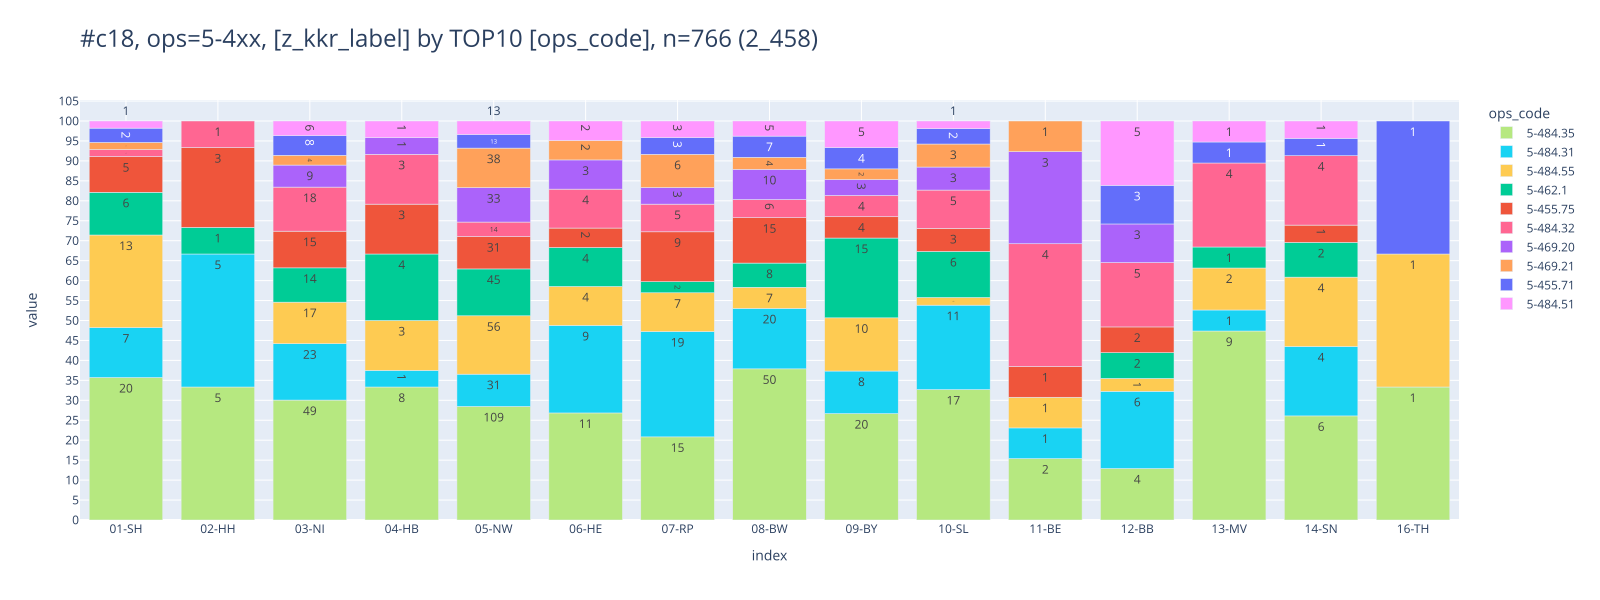

In [21]:
_filter = f"""--sql
    z_icd10_3d in ('C19')
    and left(ops.Code,3) in ('5-4')
    and {FILTER_DEFAULT}
"""

show_ops(_filter)

Anzahl verschiedene ops_codes:  4889
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-484.55 - Rektumresektion unter Sphinktererhaltung: Tiefe anteriore Resektion: Laparoskopisch mit Anastomose                       │    9580 │
│ 5-462.1 - Anlegen eines Enterostomas (als protektive Maßnahme) im Rahmen eines anderen Eingriffs: Ileostoma                         │    9505 │
│ 5-484.35 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Laparoskopi

<!-- START_TOKEN -->

# filter

    z_icd10_3d in ('C20')
    and left(ops.Code,3) in ('5-4')
    and 
    z_dy between 2020 and 2024




<!-- END_TOKEN -->

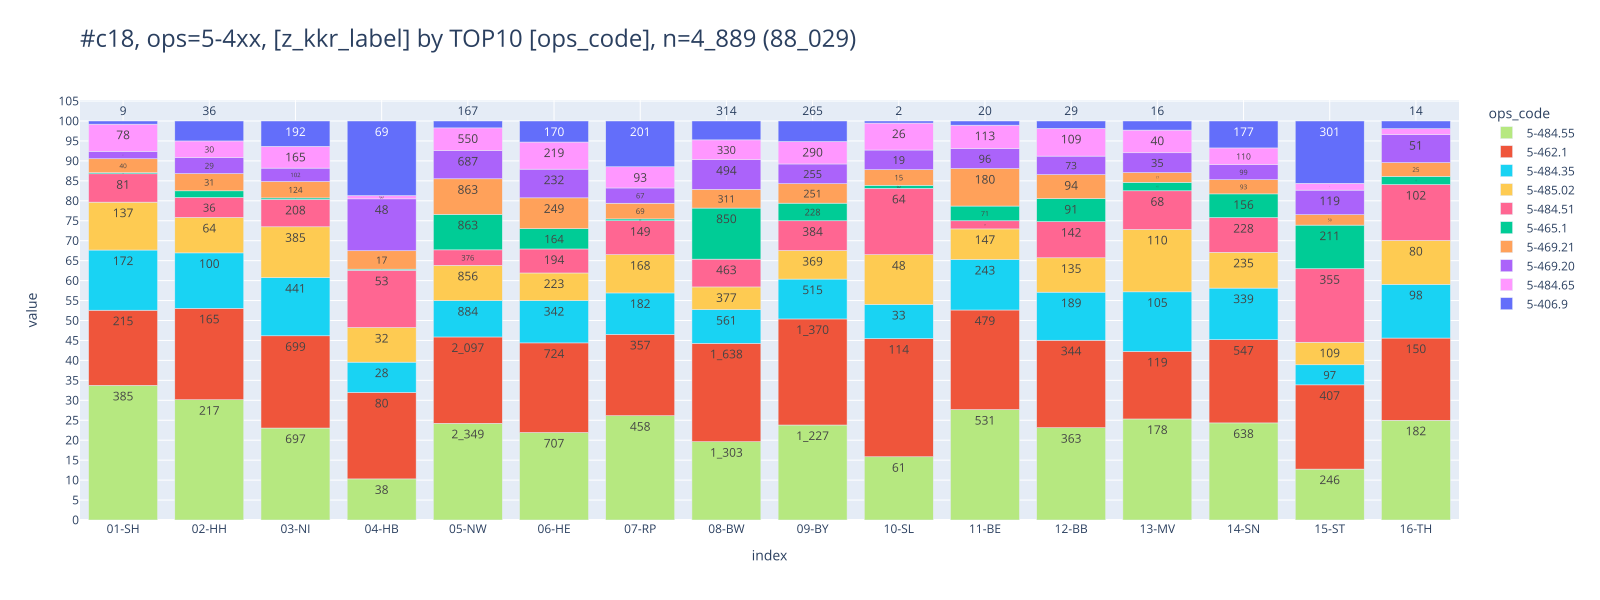

In [22]:
_filter = f"""--sql
    z_icd10_3d in ('C20')
    and left(ops.Code,3) in ('5-4')
    and {FILTER_DEFAULT}
"""

show_ops(_filter)

### <a id='toc1_5_2_'></a>[ Verteilung OPS 5-455 bei C18](#toc0_)
- Filter: `C18` und `M0`
- gezählt sind Tumore
- `has_5-455`: True wenn Tumor >= 1 OPS 5-455 hat
> 💡 Erwartet sind ~95% Anteil für True, tatsächlich sind es für D ~75%

FILTER: z_icd10_3d = 'C18' and z_m_pc_1 = '0'



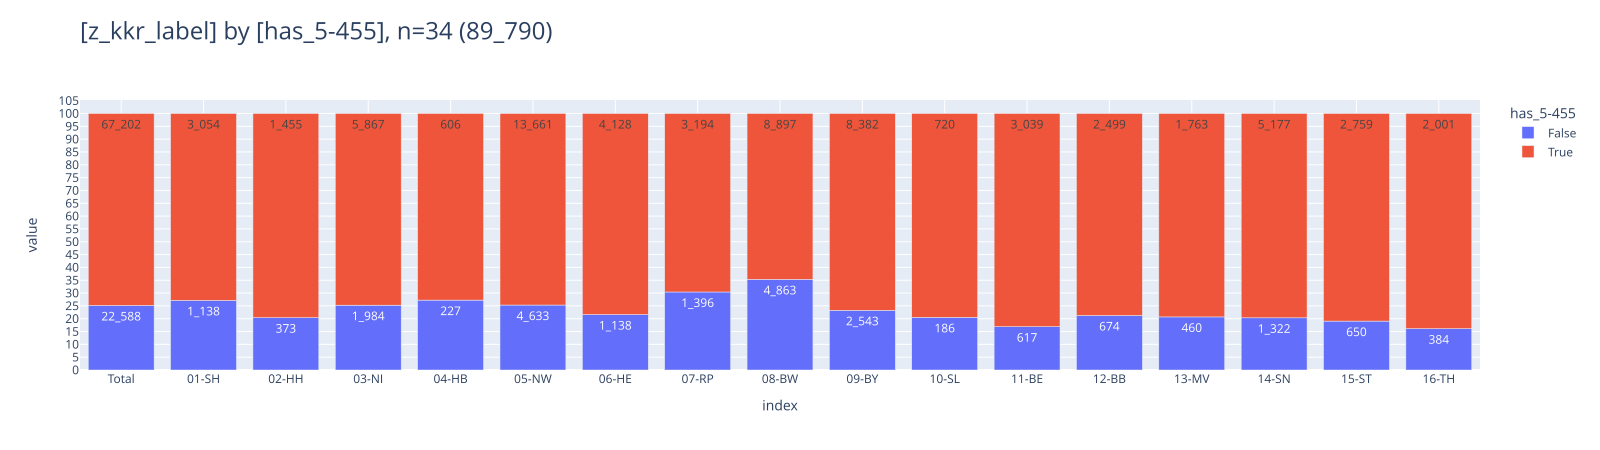

In [23]:
FILTER = "z_icd10_3d = 'C18' and z_m_pc_1 = '0'"
df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) = '5-455')) as 'has_5-455',
        FROM (select * from Tumor where {FILTER_DEFAULT} and {FILTER}) tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
)
print(f"FILTER: {FILTER}\n")
_=pls.plot_stacked_bars(df, relative=True, show_total=True, orientation="v", height=450)

### <a id='toc1_5_3_'></a>[ Verteilung OPS 5-484 bei C20](#toc0_)
- Filter: `C18` und `M0`
- `has_5-48x`: True wenn Tumor >= 1 OPS 5-484 oder 5-485 hat
> 💡 ~40% haben True, weniger als erwartet 

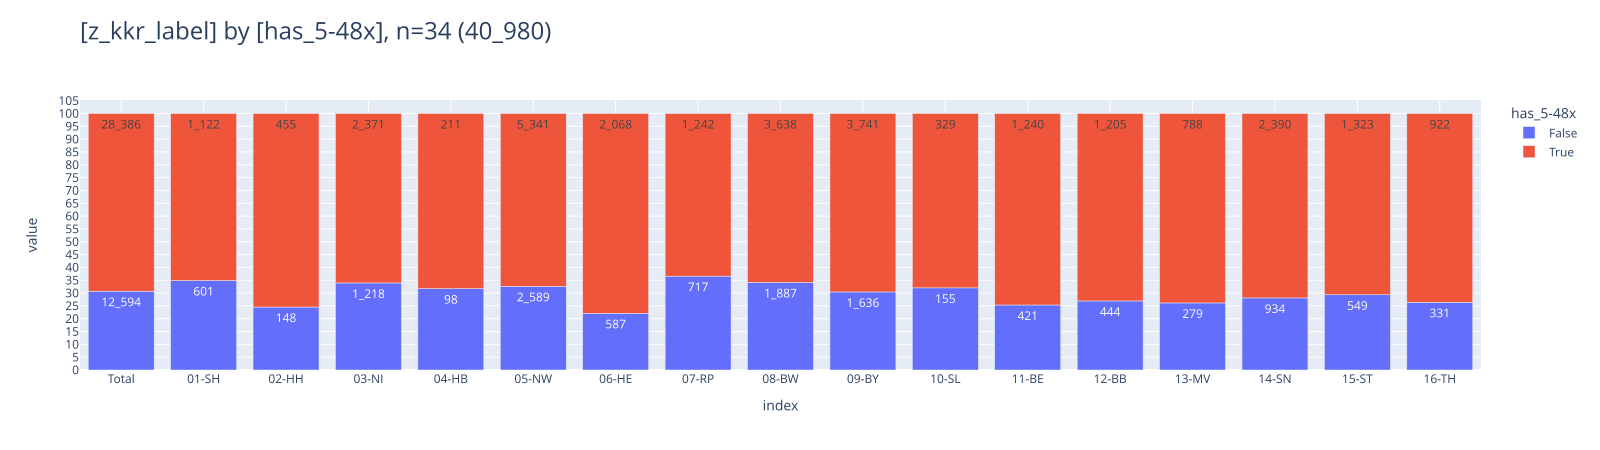

In [24]:
df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) in ('5-484', '5-485'))) as 'has_5-48x',
        FROM (select * from Tumor where {FILTER_DEFAULT} and z_icd10_3d = 'C20' and z_m_pc_1 = '0') tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
)
_=pls.plot_stacked_bars(df, relative=True, show_total=True, orientation="v", height=450)

### <a id='toc1_5_4_'></a>[Details OPS 5-455.2](#toc0_)
- Filter: `C18-C20`, alle Tumore mit min 1 OP
- gezählt sind Tumore / OPS
- die Gruppen können überlappen bei der Tumordarstellung
  - `lleo` - Ileozökalresektion
  - `hemi` - rechte Hemikolektomie
  - `sigma` - Sigmaresektion
- in allen Darstellungen ist Robotik ebenfalls angegeben (`5-987`) bzw `5-987.01`
  <!-- - `-` - keine der genannten OPS -->

In [53]:
FILTER_OP_COUNT = "z_tum_op_count > 0"
FILTER_OPS = """--sql
    (
        left(Code,7) in ('5-455.2', '5-455.4', '5-455.7')
        OR left(Code,5) in ('5-987')
    )
"""

_filter = f"""
    {FILTER_DEFAULT}
    and {FILTER_COLORECTAL}
    and {FILTER_OPS}
"""

FILTERS = [
    (FILTER_OP_COUNT, ""),
    (FILTER_OPS, "ops"),
]

_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}""",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 227_053                         (100.0%) ██████████████████████████████
└ [z_tum_op_count > 0]: n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [ops]:                 n = 70_180  (30.9%) ░░░░░░░░░░░░░░░░░░░░░█████████


<!-- END_TOKEN -->

<!-- START_TOKEN -->

# filter

    
    z_dy between 2020 and 2024

    and z_icd10_3d in ('C18','C19','C20')
    and (left(Code,8) in ('5-455.41', '5-455.45', '5-455.47') OR left(Code,5) in ('5-987'))



<!-- END_TOKEN -->

┌──────────────────────────────────────┬──────────┬──────────┬───────────┬───────────────┬──────────┐
│               z_tum_id               │ has_lleo │ has_hemi │ has_sigma │ has_robo_true │ has_robo │
│               varchar                │ boolean  │ boolean  │  boolean  │    boolean    │ boolean  │
├──────────────────────────────────────┼──────────┼──────────┼───────────┼───────────────┼──────────┤
│ 72115c5c-d3f8-4e6d-88a5-3318a75bee72 │ false    │ false    │ false     │ true          │ false    │
│ 6caa10cf-5ca9-445e-8081-c915f6fe71a4 │ false    │ false    │ false     │ true          │ true     │
└──────────────────────────────────────┴──────────┴──────────┴───────────┴───────────────┴──────────┘

n = 49_413 | n(true) = 49_413


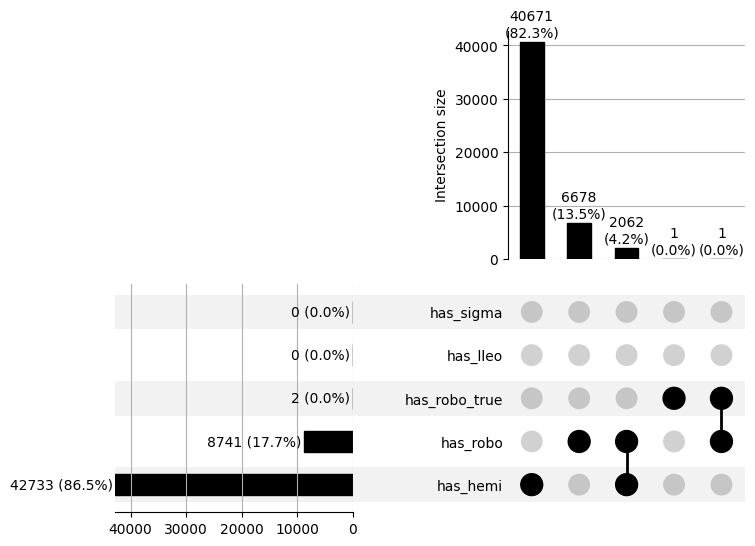

In [71]:
db_ops_upset = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,7) in ('5-455.2') then true else false end as lleo,
            case when left(ops.Code,7) in ('5-455.4') then true else false end as hemi,
            case when left(ops.Code,7) in ('5-455.7') then true else false end as sigma,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') and not robo_true then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter}
    ), t2 as (
        select
            z_tum_id,
            max(lleo) as has_lleo,
            max(hemi) as has_hemi,
            max(sigma) as has_sigma,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
hlp.print_filter(_filter)

# ? debug
db_ops_upset.filter("has_robo_true").show()
# hlp.get_tum_details("6caa10cf-5ca9-445e-8081-c915f6fe71a4", con=con)

pls.plot_upset(db_ops_upset.to_df().iloc[:,-5:], include_false_subsets=False)

#### <a id='toc1_5_4_1_'></a>[Ileozökalresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.2` aufweisen
- Gruppen
  - `5-455.21` - offen
  - `5-455.25` - laparoskopisch
  - `5-455.27` - konversion

> 💡 keine Robotik `5-987.1` geschlüsselt für diese Tumore

In [ ]:
FILTER_OPS_LLEO = "(left(Code,8) in ('5-455.21', '5-455.25', '5-455.27') OR left(Code,5) in ('5-987'))"
_filter = f"""
    {FILTER_DEFAULT}
    and {FILTER_COLORECTAL}
    and {FILTER_OPS_LLEO}
"""

FILTERS = [
    (FILTER_OP_COUNT, ""),
    (FILTER_OPS_LLEO, "ops-lleo"),
]
_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}""",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 227_053                         (100.0%) ██████████████████████████████
└ [z_tum_op_count > 0]: n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [ops-lleo]:            n = 10_087   (4.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<!-- START_TOKEN -->

# filter

    
    z_dy between 2020 and 2024

    and z_icd10_3d in ('C18','C19','C20')
    and 
    (
        left(Code,7) in ('5-455.2', '5-455.4', '5-455.7')
        OR left(Code,5) in ('5-987')
    )




<!-- END_TOKEN -->

n = 70_180 | n(true) = 10_087


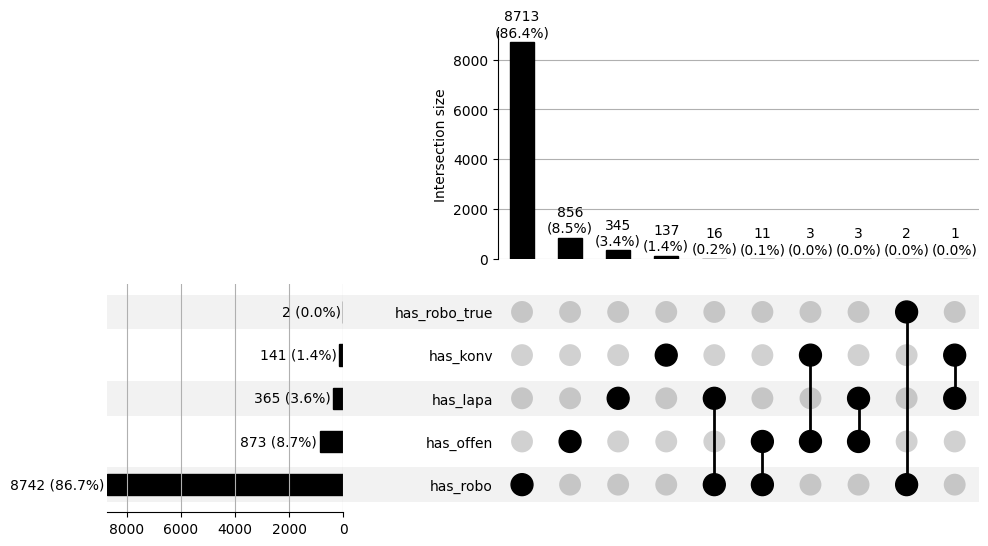

In [61]:
db_ops_upset_4552 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.21') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.25') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.27') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
hlp.print_filter(_filter)

# ? debug
# db_ops_upset_4552.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4552.to_df().iloc[:,-5:],include_false_subsets=False)

#### <a id='toc1_5_4_2_'></a>[rechte Hemikolektomie](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.4` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

In [73]:
FILTER_OPS_HEMI = """--sql
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )
"""

_filter = f"""
    {FILTER_DEFAULT}
    and {FILTER_COLORECTAL}
    and {FILTER_OPS_HEMI}
"""

FILTERS = [
    (FILTER_OP_COUNT, ""),
    (FILTER_OPS_HEMI, "ops-hemi"),
]

_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}""",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 227_053                         (100.0%) ██████████████████████████████
└ [z_tum_op_count > 0]: n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [ops-hemi]:            n = 49_413  (21.8%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<!-- START_TOKEN -->

# filter

    
    z_dy between 2020 and 2024

    and z_icd10_3d in ('C18','C19','C20')
    and 
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )




<!-- END_TOKEN -->

n = 49_413 | n(true) = 49_413


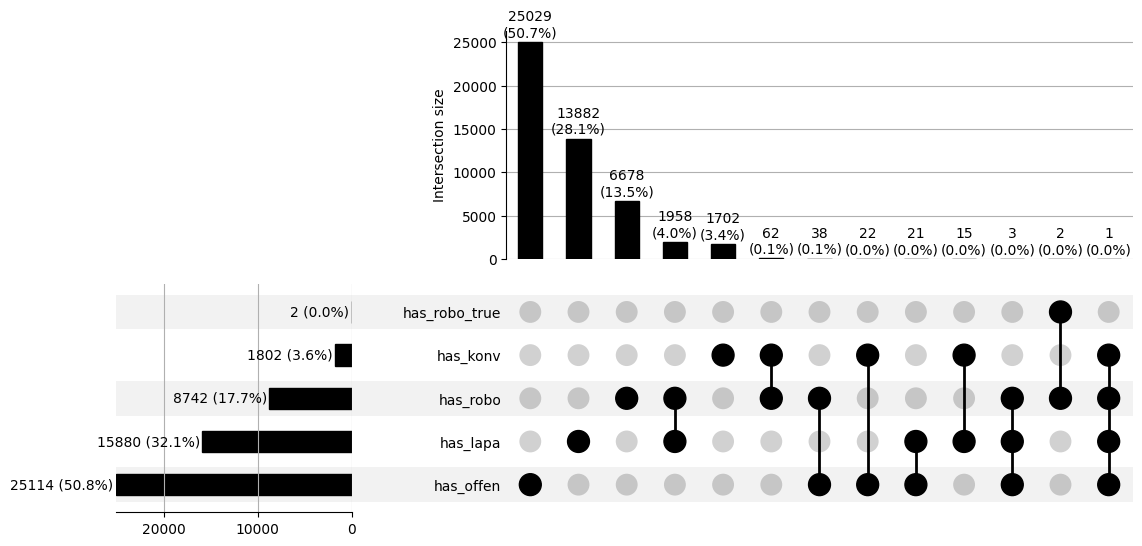

In [74]:
db_ops_upset_4554 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.41') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.45') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.47') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
hlp.print_filter(_filter)

# ? debug
# db_ops_upset_4554.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4554.to_df().iloc[:,-5:],include_false_subsets=False)

#### <a id='toc1_5_4_3_'></a>[Sigmaresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.7` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

In [75]:
FILTER_OPS_SIG = """--sql
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )
"""

_filter = f"""
    {FILTER_DEFAULT}
    and {FILTER_COLORECTAL}
    and {FILTER_OPS_SIG}
"""


FILTERS = [
    (FILTER_OP_COUNT, ""),
    (FILTER_OPS_SIG, "ops-sigma"),
]
_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}""",
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 227_053                         (100.0%) ██████████████████████████████
└ [z_tum_op_count > 0]: n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [ops-sigma]:           n = 20_619   (9.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<!-- START_TOKEN -->

# filter

    
    z_dy between 2020 and 2024

    and z_icd10_3d in ('C18','C19','C20')
    and 
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )




<!-- END_TOKEN -->

n = 20_619 | n(true) = 20_619


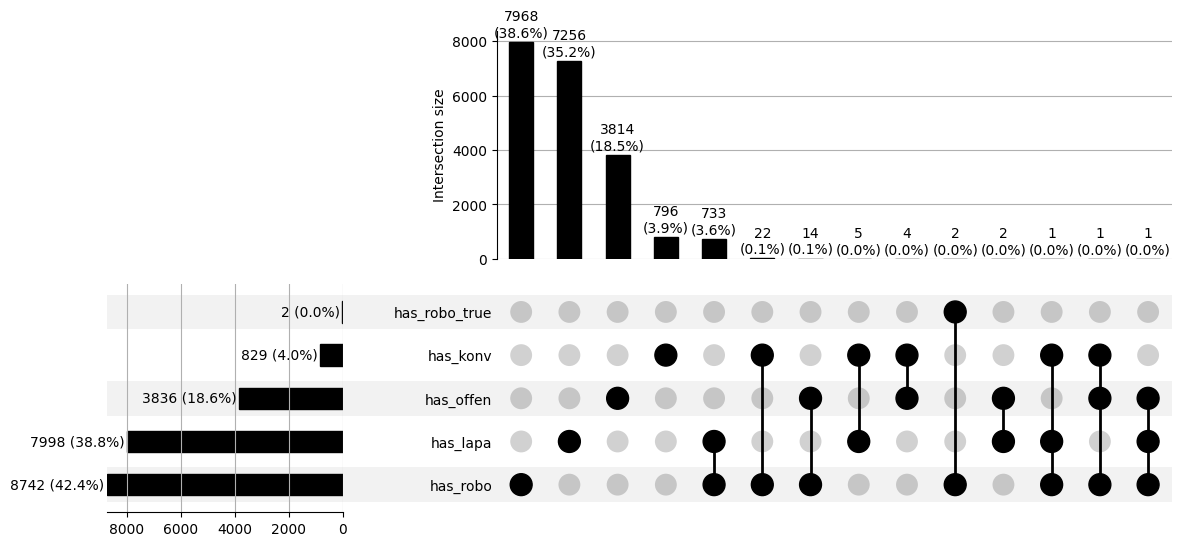

In [76]:
db_ops_upset_4557 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.71') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.75') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.77') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
hlp.print_filter(_filter)

# ? debug
# db_ops_upset_4557.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4557.to_df().iloc[:,-5:],include_false_subsets=False)

## <a id='toc1_6_'></a>[Lokalisation (Fernmetastasen)](#toc0_)


### <a id='toc1_6_1_'></a>[für M1](#toc0_)
- Filter: `C18`-`C20`, nur `M1`
- gezählt sind Tumore. Allerdings: Bei mehrfachen FM Angaben werden Tumore **mehrfach** gezählt

> 💡 50% von M1 haben Leber FM


In [34]:
fm1 = db_colon.filter("z_m_pc_1 in ('1')").count("distinct z_tum_id").fetchall()[0][0]
fm0 = db_colon.filter("z_m_pc_1 in ('0')").count("distinct z_tum_id").fetchall()[0][0]
print(f"{fm1:_} Tumore im Filter haben M1, {fm0:_} haben M0")

357_538 Tumore im Filter haben M1, 390_224 haben M0


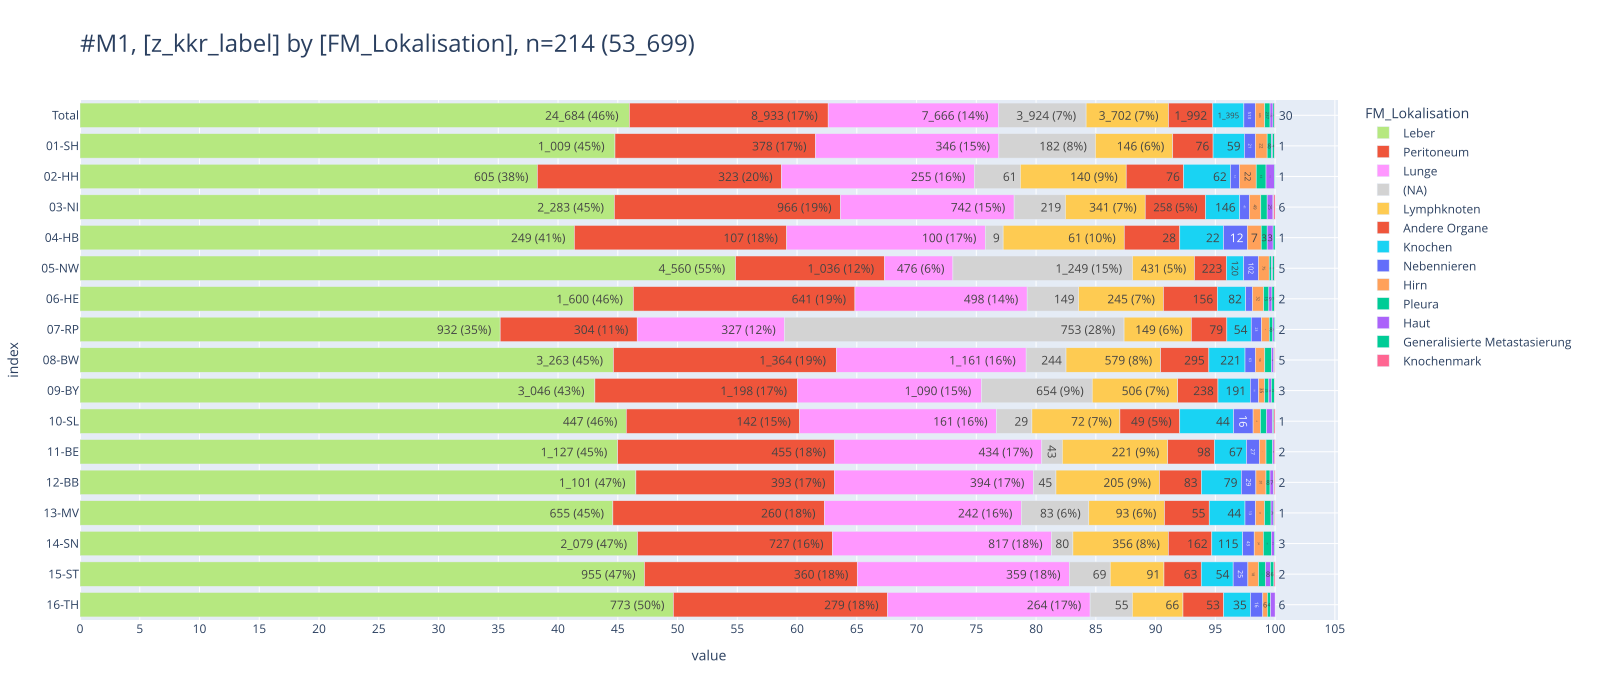

In [35]:

df = (db_colon
    .filter("z_m_pc_1 in ('1')")
    .aggregate("""--sql
            z_kkr_label, FM_Lokalisation,
            count(distinct z_tum_id) as cnt_tum
        """)
    .to_df()
)

_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=700,
    width=1600,
    caption="M1",
    sort_values_color=True,
    show_pct_bar=True,
)
# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

## <a id='toc1_7_'></a>[Rezidive](#toc0_)

### <a id='toc1_7_1_'></a>[Verteilung OP in 2020](#toc0_)
- Filter: `C18`-`C20`, 2020
- gezählt sind Tumore
- Einteilung der Verteilung in eine Kategorie Tabelle
  - `1_op_r0` - OP und R0 dokumentiert
  - `2_op_no_r0` - OP, kein R0
  - `3_no_op_but_pt` - keine OP, aber pT (Diagnose oder Verlauf)
  - `4_no_op_pt_but_st_sy` - keine OP, keine pT, aber ST oder SYST
  - `5_no_op_st_sy_pt` - keine Therapie oder pT


In [77]:
FILTER_2020 = "z_dy = 2020"
FILTER = f"{FILTER_DEFAULT} and {FILTER_COLORECTAL} and {FILTER_2020}"

FILTERS = [
    (FILTER_2020, ""),
]
_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}
        """,
    filters=FILTERS,
    # distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: rows
---
n = 227_053                  (100.0%) ██████████████████████████████
└ [z_dy = 2020]:  n = 57_102  (25.1%) ░░░░░░░░░░░░░░░░░░░░░░░███████


<!-- END_TOKEN -->

In [37]:
# FILTER = f"z_dy = 2020 and {FILTER_COLORECTAL}"
# 49_284 Operationen, 57_102 Tumore
db_r0 = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id,
                z_kkr_label,
                upper(left(op.Lokale_Beurteilung_Residualstatus,2)) as r_status,
                z_tum_op_count,
                z_tum_sy_count,
                z_tum_st_count,
                z_t_p_1 as pt_tum,
                case when
                    (ifnull(fo.T,'0') <> '0' and fo.c_p_u_Praefix_T = 'p')
                    or ifnull(z_t_p_1,'0') <> '0'
                    then true else false end as has_pt,
                case when z_tum_sy_count > 0 or z_tum_st_count > 0 then true else false end as has_st_sy,
                fo.T as t_fo,
                fo.c_p_u_Praefix_T as cpu_fo
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join OP op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM fo on fo.z_tum_id = tum.z_tum_id
        where {FILTER}
    ),
    t2 as (
        select  z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                any_value(z_tum_op_count) as z_tum_op_count,
                any_value(z_tum_sy_count) as z_tum_sy_count,
                any_value(z_tum_st_count) as z_tum_st_count,
                max(ifnull(r_status,'')='R0') as has_r_status,
                max(has_st_sy) as has_st_sy,
                max(has_pt) as has_pt,
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  *,
                case
                    when z_tum_op_count = 0 and not has_st_sy and not has_pt then '1_no_op_st_sy_pt'
                    when z_tum_op_count = 0 and not has_st_sy and has_pt then '2_no_op_st_sy_but_pt'
                    when z_tum_op_count = 0 and has_st_sy and not has_pt then '3_no_op_pt_but_st_sy'
                    when z_tum_op_count = 0 and has_st_sy and has_pt then '4_no_op_but_st_sy_pt'
                    when not has_r_status then '5_op_no_r0'
                    when has_r_status then '6_op_r0'
                    else '9_unknown'
                end as categ_op_r0__,
                case
                    when z_tum_op_count = 0 then '1_no_op'
                    when not has_r_status then '2_op_no_r0'
                    when has_r_status then '3_op_r0'
                    else '9_unknown'
                end as categ_op_r0_,
                case
                    when z_tum_op_count > 0 and has_r_status then '1_op_r0'
                    when z_tum_op_count > 0 and not has_r_status then '2_op_no_r0'
                    when has_pt then '3_no_op_but_pt'
                    when has_st_sy then '4_no_op_pt_but_st_sy'
                    when not has_st_sy then '5_no_op_st_sy_pt'
                    else '9_unknown'
                end as categ_op_r0,
                
        from t2
    )
    select * from t3
""")

n_tum = con.sql("""select count(distinct z_tum_id) from db_r0""").fetchone()[0]
n_op = con.sql("""select sum(z_tum_op_count) from db_r0""").fetchone()[0]
# print(f"FILTER: {FILTER} | darin {n_op:_} Operationen, {n_tum:_} Tumore")

# tbl.descr_db(db_r0
#     # .filter("has_st_sy")
#     , "r0")
# db_r0.filter("left(categ_op_r0,1) = '3'").show()

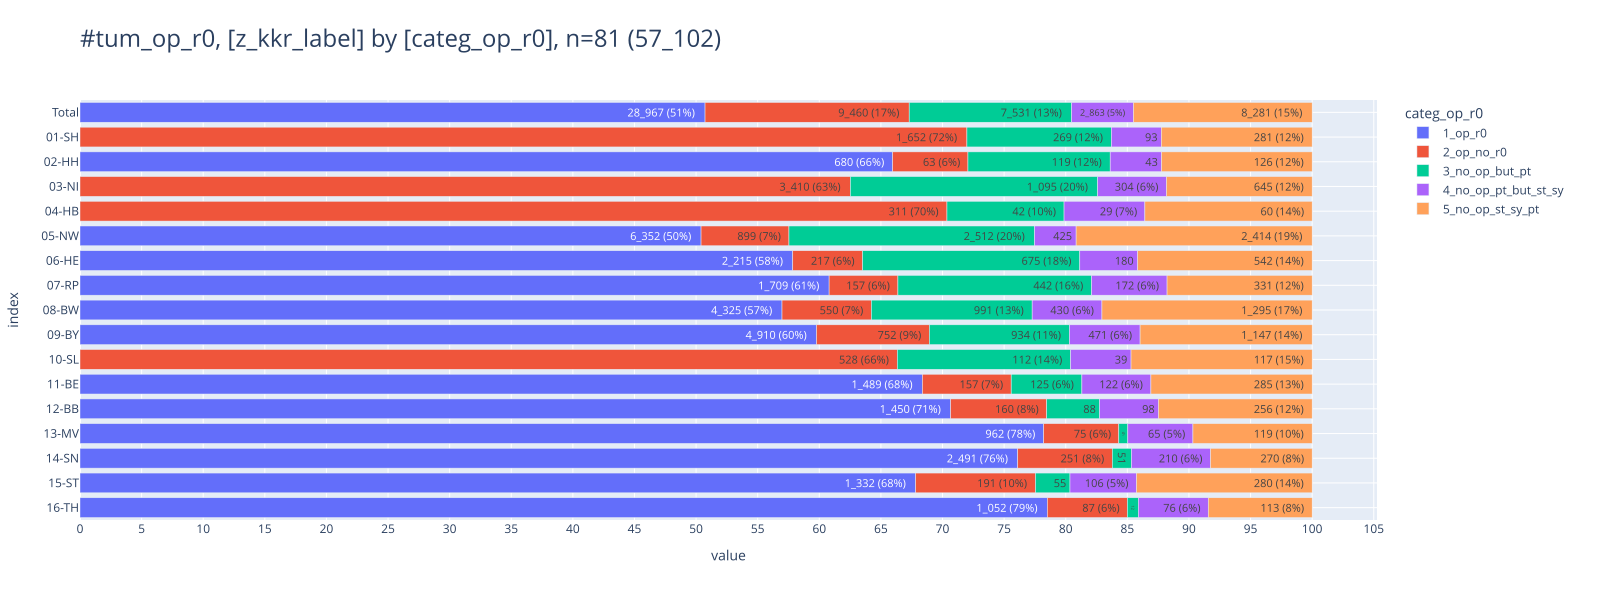

In [38]:

pls.plot_stacked_bars(
    db_r0.project("z_kkr_label, categ_op_r0").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_op_r0",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
    )
# tbl.pivot_df(db_r0.project("z_kkr_label, categ_op_r0").to_df(), swap=False, )

#### <a id='toc1_7_1_1_'></a>[davon: Verteilung nur R0](#toc0_)

**enge Definition eines Rezidivs** 
- Filter: lokaler Beurteilung Residualstatus = R0 (UND M <> 1)
- Rezidiv wenn  
  - Gesamtbeurteilung: Y  oder  
  - Lokaler Tumorstatus: R  oder  
  - Tumorstatus Lymphknoten:R oder  
  - Verlauf Fernmetastasen:R   

**erweiterte Definition (Verworfen)**
- Rezidiv wenn
  - (TNM)r_Symbol:r UND 
  - (Folgeereignis T>0 oder Folgeereignis N>0 oder Folgeereignis M>0)

**Diagramm**
- gezählt sind Tumore mit R0
- Kategorien
  - `1_fo_relapse` - Tumore mit Rezidiv nach enger Definition
  - `2_fo_relapse_tnm` - Tumore mit Rezidiv nach erweiterter Definition
  - `3_fo_no_relapse` - Tumore mit Folgeereignis ohne o.a. Rezidiv
  - `4_no_fo` - Tumore ohne Folgeereignis
  - `9_unknown` - Unbekannt

In [78]:
FILTER_R0 = "upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'"
FILTER = f"{FILTER_DEFAULT} and {FILTER_COLORECTAL} and {FILTER_2020} and {FILTER_R0}"

FILTERS = [
    (FILTER_2020, ""),
    (FILTER_R0, "Residualstatus R0"),
]
_=hlp.get_duckdb_filter_n(
    con=con,
    query=f"""--sql
        from Tumor tum
        left join OP op on op.z_tum_id = tum.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}
        """,
    filters=FILTERS,
    distinct_metric="z_tum_id",
)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 227_053                        (100.0%) ██████████████████████████████
└ [z_dy = 2020]:        n = 57_102  (25.1%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [Residualstatus R0]:  n = 28_967  (12.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███


<!-- END_TOKEN -->

In [40]:
db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id
                ,z_pat_id
                ,fol.FolgeereignisId
                ,z_kkr_label
                ,z_m_pc_1
                ,fol.Gesamtbeurteilung_Tumorstatus
                ,fol.Verlauf_Lokaler_Tumorstatus 
                ,fol.Verlauf_Tumorstatus_Lymphknoten
                ,fol.Verlauf_Tumorstatus_Fernmetastasen
                ,r_Symbol
                ,T, N, M
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {FILTER_DEFAULT} and {FILTER}
        --and ifnull(z_m_pc_1,'0') <> '1'
    ),
    t2 as (
        select  *
                ,(Gesamtbeurteilung_Tumorstatus ==  'Y') as has_gesamt
                ,(Verlauf_Lokaler_Tumorstatus == 'R') as has_lokal
                ,(Verlauf_Tumorstatus_Lymphknoten == 'R') as has_lymph
                ,(Verlauf_Tumorstatus_Fernmetastasen == 'R') as has_fm
                -- extended
                ,(r_Symbol is not null) as has_r_symbol
                ,(left(T,1) in ('1','2','3','4')) as has_t2plus
                ,(left(N,1) in ('1','2','3','4')) as has_n2plus
                ,(left(M,1) in ('1','2','3','4')) as has_m2plus
        from t1
    ),
    t3 as (
        select  z_tum_id
                ,first(z_pat_id) as z_pat_id
                ,first(FolgeereignisId) as FolgeereignisId
                ,first(z_m_pc_1) as z_m_pc_1
                ,first(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_gesamt)::text as has_gesamt
                ,max(has_lokal)::text as has_lokal
                ,max(has_lymph)::text as has_lymph
                ,max(has_fm)::text as has_fm
                ,max(has_r_symbol)::text as has_r_symbol
                ,max(has_t2plus)::text as has_t2plus
                ,max(has_n2plus)::text as has_n2plus
                ,max(has_m2plus)::text as has_m2plus
        from t2
        group by z_tum_id
    ),
    t4 as (
        select  t3.*
                ,pat.Verstorben
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) then true else false end as has_rel1
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) or ((has_t2plus or has_n2plus or has_m2plus)) then true else false end as has_rel2
                ,case 
                    when FolgeereignisId is not null and (has_gesamt or has_lokal or has_lymph or has_fm) then '1_fo_relapse'
                    when FolgeereignisId is not null and has_r_symbol and (has_t2plus or has_n2plus or has_m2plus) then '2_fo_relapse_tnm'
                    --when FolgeereignisId is not null and Verstorben = 'J' then '3_fo_deceased'
                    when FolgeereignisId is not null then '3_fo_no_relapse'
                    when FolgeereignisId is null then '4_no_fo'
                    else '9_unknown'
                end as categ_relapse
        from t3
        join Patient pat on pat.oBDS_RkiPatientId = t3.z_pat_id
    )
    select * from t4
""")
# tbl.descr_db(db_rez, "relapse")
n_tum = con.sql("select count(*) from db_rez").fetchone()[0]
# print(f"FILTER: {FILTER} | darin {n_tum:_} Tumore")

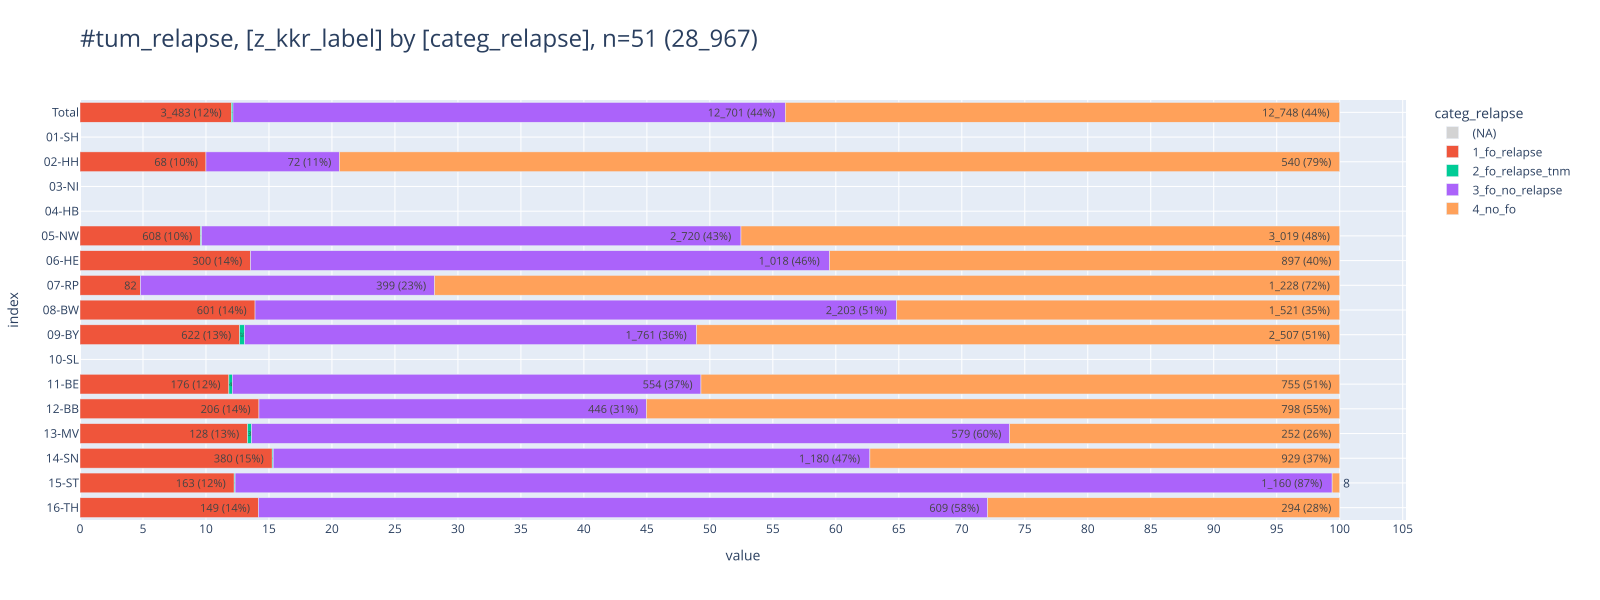

categ_relapse,1_fo_relapse,2_fo_relapse_tnm,3_fo_no_relapse,4_no_fo,Total
z_kkr_label,,,,,
02-HH,68 (0.2%),0,72 (0.2%),540 (1.9%),680 (2.3%)
05-NW,608 (2.1%),5 (0.0%),2_720 (9.4%),3_019 (10.4%),6_352 (21.9%)
06-HE,300 (1.0%),0,1_018 (3.5%),897 (3.1%),2_215 (7.6%)
07-RP,82 (0.3%),0,399 (1.4%),1_228 (4.2%),1_709 (5.9%)
08-BW,601 (2.1%),0,2_203 (7.6%),1_521 (5.3%),4_325 (14.9%)
09-BY,622 (2.1%),20 (0.1%),1_761 (6.1%),2_507 (8.7%),4_910 (17.0%)
11-BE,176 (0.6%),4 (0.0%),554 (1.9%),755 (2.6%),1_489 (5.1%)
12-BB,206 (0.7%),0,446 (1.5%),798 (2.8%),1_450 (5.0%)
13-MV,128 (0.4%),3 (0.0%),579 (2.0%),252 (0.9%),962 (3.3%)


In [41]:
pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_relapse",
    height=600,
    width=1600,
    kkr_col="z_kkr_label"
)

tbl.pivot_df(db_rez.project("z_kkr_label, categ_relapse").to_df(), swap=False, )

<br>

## <a id='toc1_8_'></a>[Behandlung innerhalb von 6 Wochen](#toc0_)
- Filter: `C18`-`C20`
- `first_treatment_6w`
  - `<=6w`: erste Behandlung innerhalb von 6 Wochen
  - `>6w`: erste Behandlung nach 6 Wochen
  - `no delta`: Behandlung ist dokumentiert, aber kein Abstand
  - `-`: keine Behandlung dokumentiert

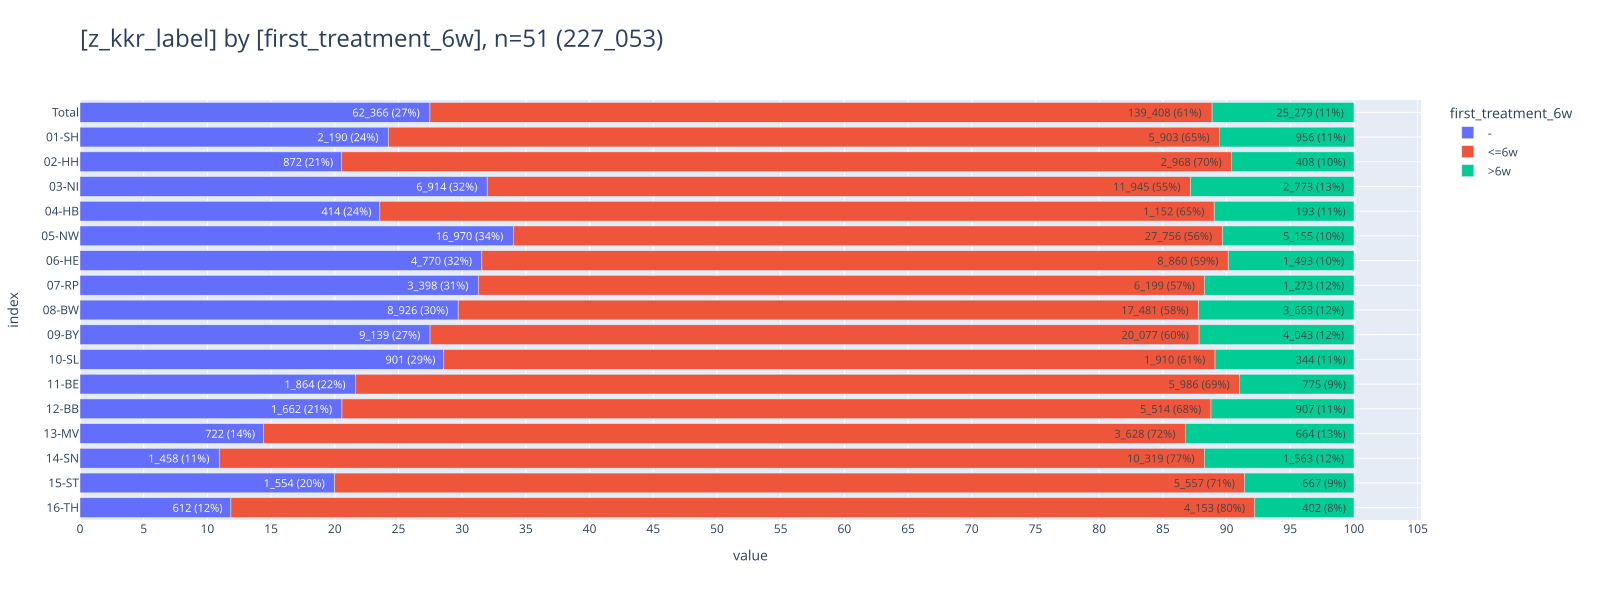

In [42]:
df = con.sql("""--sql
    with t1 as (
        select
            z_tum_id,
            z_kkr_label,
            case
                when z_first_treatment_after_days < 43 then '<=6w'
                when z_first_treatment_after_days >= 43 then '>6w'
                when z_first_treatment is not null then 'no delta'
            else '-' end
            as first_treatment_6w
        from db_colon
    ),
    t2 as (
        select
            z_kkr_label,
            first_treatment_6w,
            count(distinct z_tum_id) as cnt_tum
        from t1
        group by z_kkr_label,first_treatment_6w
    )
    select * from t2
""").to_df()

_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=600,
    show_pct_bar=True,
)
# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

## <a id='toc1_9_'></a>[Erste Behandlung](#toc0_)

### <a id='toc1_9_1_'></a>[Was wurde zuerst behandelt](#toc0_)
- Filter: `M1` und Tumor hat Lebermetastasen und `C18` oder `C20`
- gezählt sind Tumore

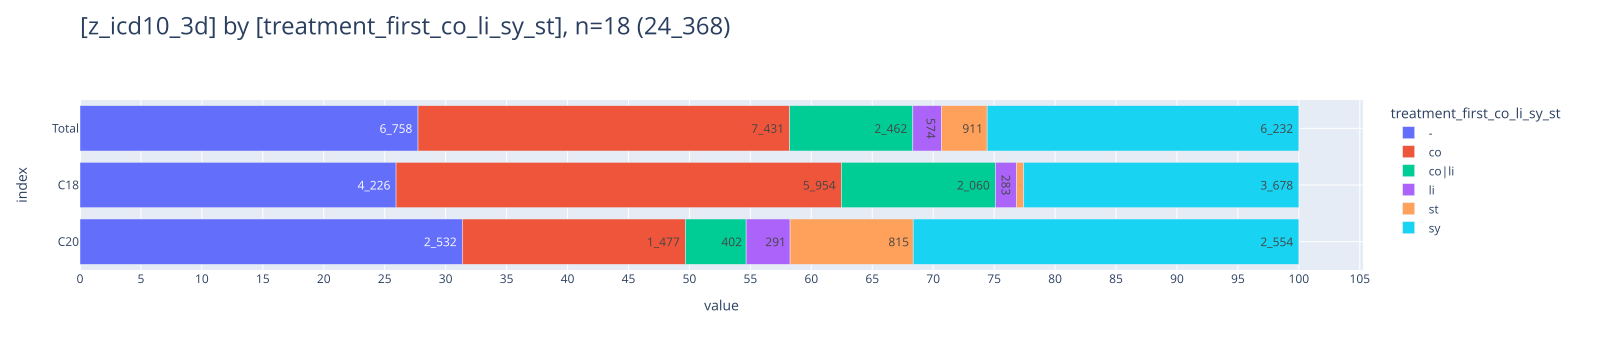

In [43]:
_df = (db_colon
    .filter("z_icd10_3d in ('C18','C20') and z_m_pc_1 = '1' and FM_Lokalisation = 'Leber'")
    .aggregate("""--sql
            z_tum_id,
            first(z_icd10_3d) as z_icd10_3d,
            first(treatment_first_co_li_sy_st) as treatment_first_co_li_sy_st, 
    """)
    )
# print(f"Anzahl Tumore: {_df.count("distinct z_tum_id").fetchall()[0][0]:_}")

_=pls.plot_stacked_bars(_df.to_df().iloc[:,-2:], relative=True, show_total=True, orientation="h", height=350)

### <a id='toc1_9_2_'></a>[Zeitlicher Abstand der Behandlungen](#toc0_)
- Filter: `C18`-`C20`, Tumore mit Behandlung
- gezählt sind Tumore
- abgebildet sind Median Werte für den Abstand Diagnose bis erste Behandlung in Tagen (logarithmische Skala)

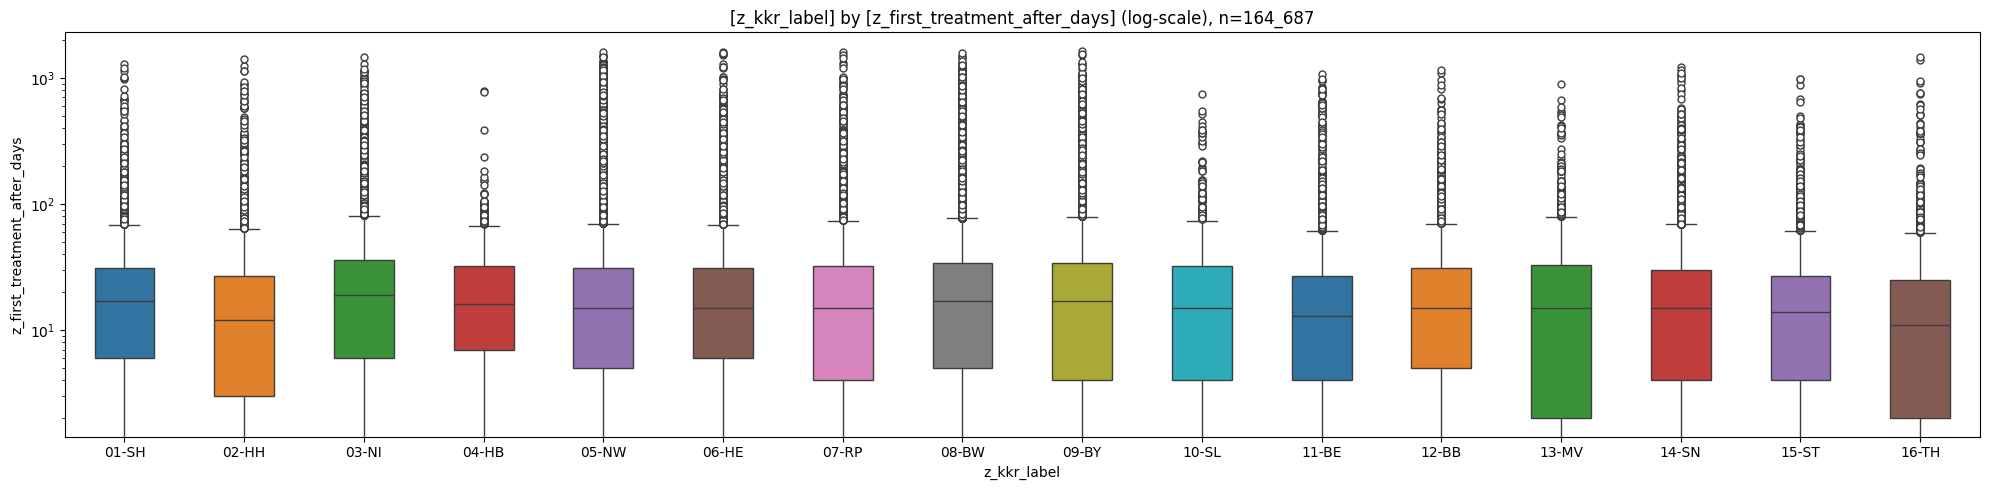


column (n = 164_687)         |    notnull     | min | lower | q25  | median | mean  |  q75  | upper |  max  |  std  |  cv 
-----------------------------+----------------+-----+-------+------+--------+-------+-------+-------+-------+-------+-----
z_first_treatment_after_days | 164_687 (100%) |   0 |     0 | 5.00 |  16.00 | 29.84 | 32.00 |    72 | 1_645 | 70.89 | 2.38


item (n = 164_687) | count  | min  | lower | q25  | median | mean  |  q75  | upper |   max    |  std  |  cv 
-------------------+--------+------+-------+------+--------+-------+-------+-------+----------+-------+-----
01-SH              |  6_859 | 0.00 |  0.00 | 6.00 |  17.00 | 26.53 | 31.00 | 68.00 | 1_279.00 | 53.83 | 2.03
02-HH              |  3_376 | 0.00 |  0.00 | 3.00 |  12.00 | 27.68 | 27.00 | 63.00 | 1_413.00 | 79.01 | 2.85
03-NI              | 14_718 | 0.00 |  0.00 | 6.00 |  19.00 | 31.70 | 36.00 | 81.00 | 1_464.00 | 66.03 | 2.08
04-HB              |  1_345 | 0.00 |  0.00 | 7.00 |  16.00 | 23.97 | 32.00 | 67.00 

In [44]:
db_delay = con.sql(f"""--sql
    select 
            z_kkr_label,
            z_first_treatment_after_days, 
            z_first_treatment
    from Tumor
    where {FILTER_DEFAULT} and {FILTER_COLORECTAL}
    and ifnull(z_first_treatment,'') <> ''
    and z_first_treatment_after_days >= 0
    """)
# tbl.descr_db(db_delay)

_ = pls.plot_boxes_large(
    # _df[["z_kkr_label", "z_first_treatment_after_days"]],
    db_delay.to_df().iloc[:,:2],
    height=500,
    width=2000,
    use_log=True,
)

## <a id='toc1_10_'></a>[Behandlungsverlauf](#toc0_)
- Filter: `C18`-`C20`, nur Tumore mit Therapie
- gezählt sind Tumore
- beschränkt auf die ersten 5 Therapien
- Therapien mit gleichem Tumor / Datum / Behandlung sind zusammengeführt
- verschiedene Therapien mit gleichem Tumor und Datum sind hier nicht entfernt

In [45]:
db_sankey = con.sql(f"""--sql
    with t1 as (
        select  t.z_tum_id
                ,op.Datum_OP as date_op
                ,Datum_Beginn_SYST as date_sy
                ,Datum_Beginn_Bestrahlung as date_be
        from    Tumor t
        left join OP op on t.z_tum_id = op.z_tum_id
        left join SYST sy on t.z_tum_id = sy.z_tum_id
        left join Bestrahlung be on t.z_tum_id = be.z_tum_id
        where {FILTER_DEFAULT} and {FILTER_COLORECTAL}
        --where z_dy >= 2020 and year(Datum_OP) >= 2020 and year(Datum_Beginn_SYST) >= 2020 and year(Datum_Beginn_Bestrahlung) >= 2020
    ),
    t2 as (
        SELECT  *
        FROM t1
        --UNPIVOT (date FOR event IN (date_op AS 'op', date_sy AS 'sy', date_be AS 'be'))
        UNPIVOT INCLUDE NULLS (
            date -- This is the value column
            FOR event IN (
                date_op AS 'op',
                date_sy AS 'sy',
                date_be AS 'be'
            )
        )
    ),
    t3 as (
        SELECT  z_tum_id
                ,date
                ,event
        FROM t2
        -- de-duplicate
        group by z_tum_id, date, event
    )
    select * from t3
""")

# tbl.descr_db(db_sankey,"sankey")

n_tum = con.sql("""select count(distinct z_tum_id) from db_sankey""").fetchone()[0]
n_tum_date = con.sql("""select count(distinct z_tum_id) from db_sankey where date is not null""").fetchone()[0]
n_events = con.sql("""select count(*) from db_sankey""").fetchone()[0]
n_events_date = con.sql("""select count(*) from db_sankey where date is not null""").fetchone()[0]

print(f"FILTER: {FILTER_COLORECTAL} | darin {n_tum:_} Tumore, {n_events:_} deduplizierte Therapien | darin mit Datum: {n_tum_date:_} Tumore, {n_events_date:_} Therapien")

FILTER: z_icd10_3d in ('C18','C19','C20') | darin 227_053 Tumore, 730_228 deduplizierte Therapien | darin mit Datum: 164_877 Tumore, 279_505 Therapien


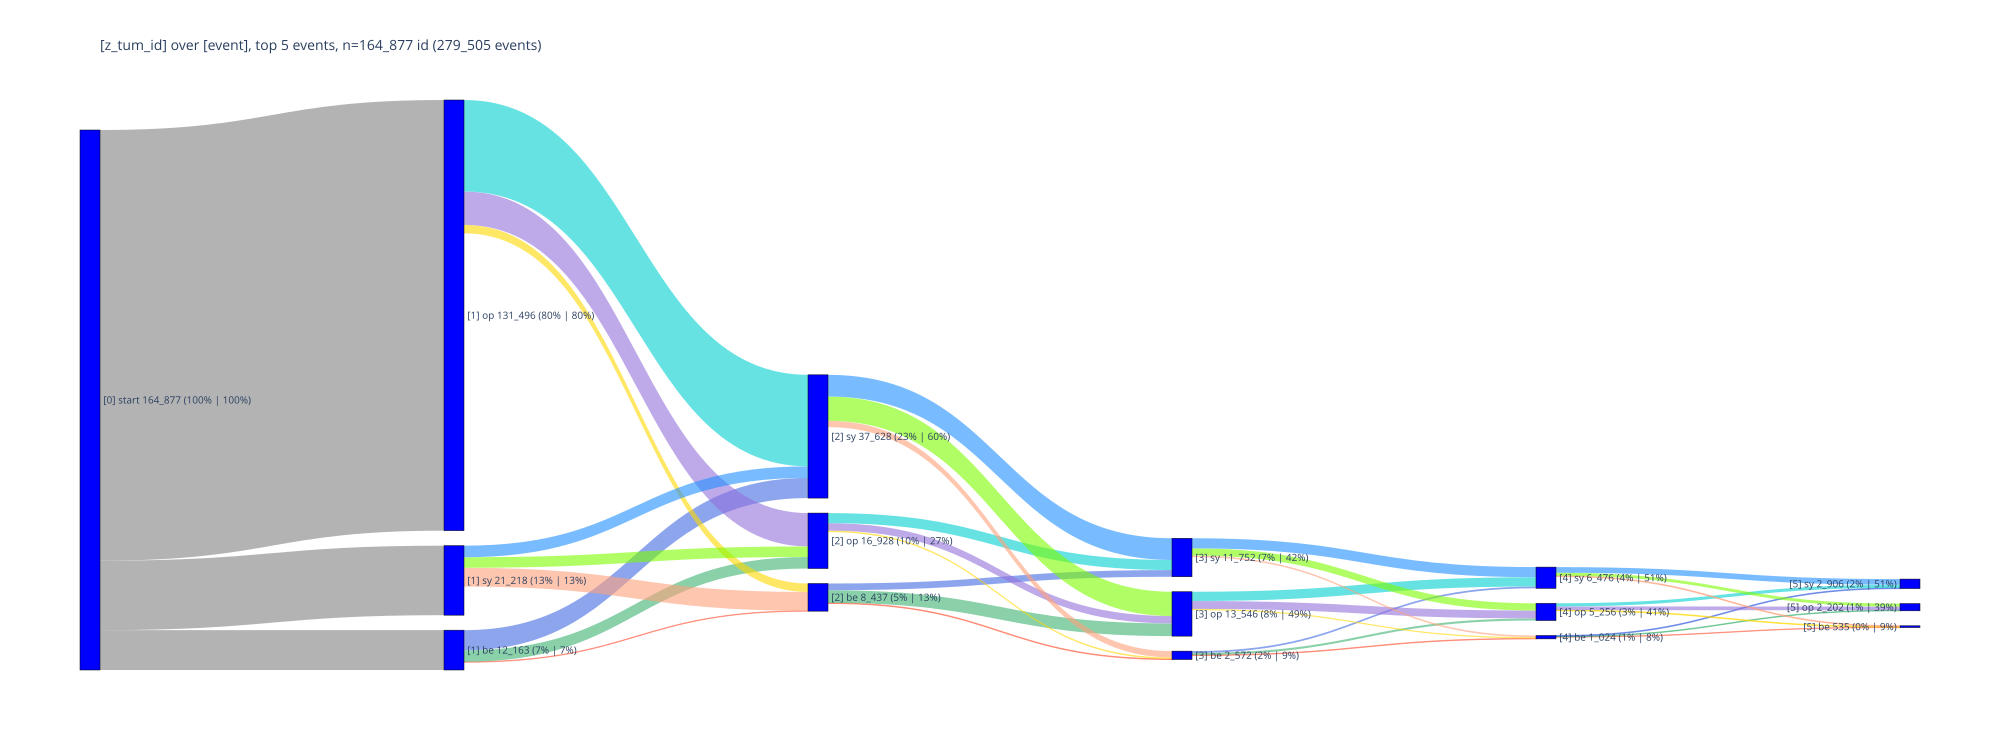

In [46]:
_df = db_sankey.to_df().dropna()
pls.plot_sankey(_df, max_events_per_id=5, exclude_overlap_event=False,height=750, width=2000,)

## <a id='toc1_11_'></a>[🕹️ interaktiv](#toc0_)

In [47]:
if False:
    import pygwalker as pyg

    spec = "config/pygwalker_spec_colo.json"
    nodes = [
        ("cnt_tum", "count(distinct z_tum_id)"),
        ("cnt_pat", "count(distinct z_pat_id)"),
        ("cnt_op", "count(distinct op_id)"),
        ("cnt_st", "count(distinct st_id)"),
        ("cnt_syst", "count(distinct syst_id)"),
    ]
    hlp.add_measures_to_pyg_config(spec, nodes=nodes)

    _ = pyg.walk(
        db_colon.to_df(),
        appearance=os.environ['THEME'],
        spec=spec,
        kernel_computation=True,
    )